# Task for session2_cont and session3: 
## Edge-Preserving Denoising Filters & Feature Matching

**Instructions:**  
**please dont use .py to solve this task, just use tasks2.ipynb and edit the cells.**
- After forking the [SkyXperts-Vision-Course repo](https://github.com/ffathy-tdx/SkyXperts-Vision-Course) on GitHub. (you should have already dont this in the last session & uploaded task1)
- Go to your fork of the repo on GitHub.
- At the top, look for a yellow box that says “This branch is X commits behind…”
- Click the Sync fork or Update branch button.
The new task will show up in your tasks/ folder.  
- Upload your task to your forked repo (like you've done with task1 before)
---

## 1. DoG, LoG, and Edge-Preserving Denoising Filters

**Task:**
- Briefly read the descriptions below, then apply each filter to `'sample.jpg'` (or any test image you choose).
- Compare the results visually and write your observations.

**Background:**
- **DoG (Difference of Gaussian):** Used for edge detection by subtracting two blurred versions of the image (with different Gaussian sigmas).
- **LoG (Laplacian of Gaussian):** Uses a single Gaussian blur followed by Laplacian to highlight regions of rapid intensity change (edges).
- **Edge-Preserving Denoising (Bilateral Filter):** Smooths image while preserving edges (unlike simple Gaussian blur). You've already used this at the end of task1.

---

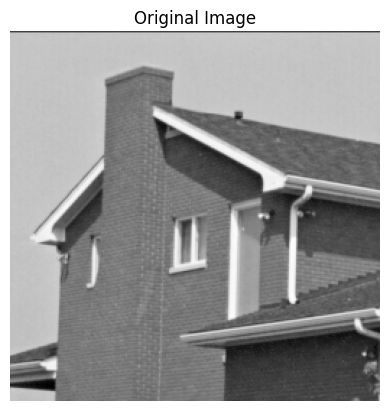

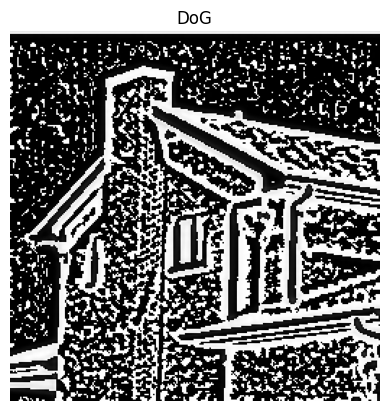

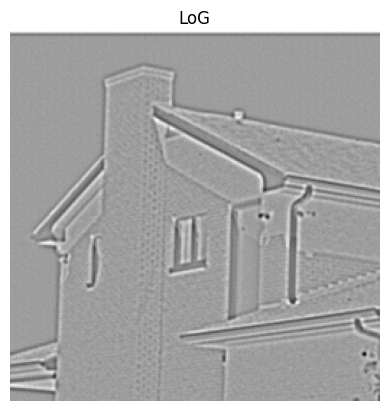

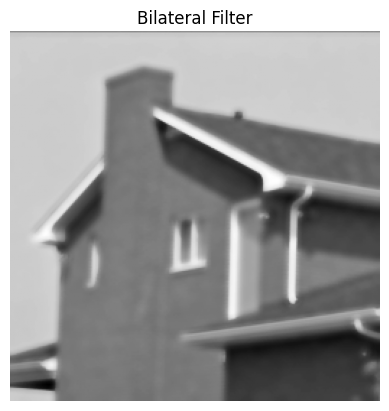

In [1]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('house.jpg', 0)  
plt.imshow(img, cmap='gray'); plt.axis('off'); plt.title('Original Image'); plt.show()

dog = cv2.GaussianBlur(img,(0, 0),1) - cv2.GaussianBlur(img,(0,0), 2)
plt.imshow(dog, cmap='gray')
plt.axis('off')
plt.title('DoG')
plt.show()

log = cv2.Laplacian(cv2.GaussianBlur(img, (0, 0), 1), cv2.CV_64F)
plt.imshow(log, cmap='gray')
plt.axis('off')
plt.title('LoG')
plt.show()

bilateral = cv2.bilateralFilter(img, 9, 75, 75)
plt.imshow(bilateral, cmap='gray')
plt.axis('off') 
plt.title('Bilateral Filter')
plt.show()


**Q1: What differences do you observe between DoG, LoG, and the edge-preserving filter?**
DoG and LoG both show edges and small details. DoG compares two blurred images, while LoG blurs an image and then finds changes. 

## 2. Keypoints & Descriptors: SIFT vs. ORB

**Task:**
- Detect and plot keypoints on `'sample.jpg'` using SIFT and ORB.
- Compare the number and distribution of detected keypoints.

**Background:**
- **Keypoints:** Distinctive image points (corners/blobs) useful for matching.
- **Descriptors:** Vectors that describe local patches around keypoints for comparison/matching.

---

In [19]:
# Detect and plot SIFT keypoints
sift = cv2.SIFT_create()

# Detect and plot ORB keypoints
orb = cv2.ORB_create()


sift_keypoints, _ = sift.detectAndCompute(img, None)
orb_keypoints, _ = orb.detectAndCompute(img, None)

print("SIFT keypoints:", len(sift_keypoints))
print("ORB keypoints:", len(orb_keypoints))




SIFT keypoints: 201
ORB keypoints: 376


**Q2: How do the number and distribution of keypoints differ between SIFT and ORB?*

SIFT usually finds more keypoints across the image, while ORB finds fewer, mostly around strong corners

## 3. Feature Matching with Descriptors

**Task:**
- Load a second image (e.g., `'sample2.jpg'`).
- Detect keypoints/descriptors using SIFT or ORB in both images.
- Match the features between the images using BFMatcher or FLANN.
- Plot the top matches.

**Background:**
- **Feature matching** helps recognize objects/scenes or estimate image transformations.

---

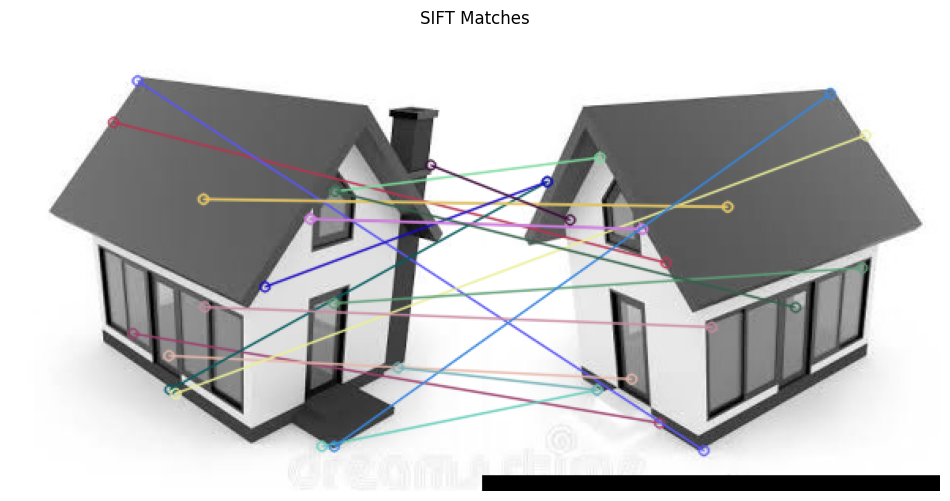

In [23]:
# Load second image
img=cv2.imread(r'.\img.jpg', 0)
img2 = cv2.imread(r'.\img2.jpg', 0)


# Detect SIFT keypoints/descriptors in both images

sift = cv2.SIFT_create()
keypoints1, descriptors1 = sift.detectAndCompute(img, None)
keypoints2, descriptors2 = sift.detectAndCompute(img2, None)

# BFMatcher with default params
bf = cv2.BFMatcher()

# Draw matches
matches = bf.knnMatch(descriptors1, descriptors2, k=2)
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)


plt.figure(figsize=(12, 6))
img_matches = cv2.drawMatches(img, keypoints1, img2, keypoints2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.imshow(img_matches)
plt.axis('off')
plt.title('SIFT Matches')
plt.show()

# bonus TODO: Try with ORB or FLANN if you like
# orb = cv2.ORB_create()
# keypoints1_orb, descriptors1_orb = orb.detectAndCompute(img, None)  
# keypoints2_orb, descriptors2_orb = orb.detectAndCompute(img2, None)




**Q3: What do you notice about the feature matches? Are there any mismatches or errors? How might you improve the matching process?**

many SIFT matches are incorrect the lines cross and connect different house features.

**Bonus Task (Optional, for extra credit):**
- Try using different image preprocessing steps *before* edge detection or feature extraction.
    - For example:
        - Add noise to your image (e.g., Gaussian noise, salt-and-pepper noise).
        - Apply a sharpening filter to your image.
    - Then, run DoG, LoG, or any edge-preserving filter and observe the changes.
- **What to do:**
    - Show the results (images/plots) for at least one type of preprocessing + edge detection.
    - Briefly explain:
        - How does noise affect edge maps or keypoints?
        - Does sharpening make features easier or harder to detect/match?

**You can add your code and observations in the cells below.**


In [ ]:
# Write your code here

_What are your observations?_
write them here

## 4. Reflection (Optional)

- What was the most challenging or interesting part of this task for you?
- Any feedback or thoughts?

_Write your reflection here._